# First- and Second-Order Optimization Methods

This notebook introduces several important methods for unconstrained numerical optimization in Julia.

We will study:

- the **gradient** and its geometric interpretation;
- **gradient descent**;
- the effect of the **learning rate**;
- **momentum**;
- **Newton's method**;
- symbolic computation of the **gradient and Hessian**.

## Learning objectives

By the end of this notebook, you should be able to:

1. Compute and interpret the gradient of a function of several variables.
2. Implement one step of gradient descent.
3. Explain how the learning rate affects convergence.
4. Implement gradient descent iteratively and visualize the iterates.
5. Explain the role of momentum.
6. Implement Newton's method using a gradient and Hessian.
7. Compute first- and second-order derivatives symbolically in Julia.


In [70]:
using Logging

global_logger(ConsoleLogger(stderr, Logging.Info; show_limited=false))

ConsoleLogger(VSCodeServer.IJuliaCore.IJuliaStdio{Base.PipeEndpoint, typeof(VSCodeServer.io_send_callback)}(IOContext(Base.PipeEndpoint(RawFD(18) open, 0 bytes waiting)), VSCodeServer.io_send_callback), ReentrantLock(nothing, 0x00000000, 0x00, Base.GenericCondition{Base.Threads.SpinLock}(Base.IntrusiveLinkedList{Task}(nothing, nothing), Base.Threads.SpinLock(0)), (4598311536, 4452733648, 0)), Info, Base.CoreLogging.default_metafmt, false, 0, Dict{Any, Int64}())

## 1. The gradient and the direction of steepest change

For a differentiable function

$f:\mathbb{R}^n\rightarrow\mathbb{R},$


the gradient is the vector


$\nabla f(x)=
\begin{bmatrix}
\frac{\partial f}{\partial x_1}\\
\vdots\\
\frac{\partial f}{\partial x_n}
\end{bmatrix}.
$

At a point $x$, the gradient points in the direction of the **steepest local increase** of the function. Therefore, the direction $
-\nabla f(x)
$ is the direction of steepest local decrease and is the basic direction used by gradient descent.

For a function of two variables, the tangent plane at $(x_0,y_0)$ is
$$ z \approx f(x_0,y_0)
+ f_x(x_0,y_0)(x-x_0)
+ f_y(x_0,y_0)(y-y_0).
$$

The following examples visualize this idea.


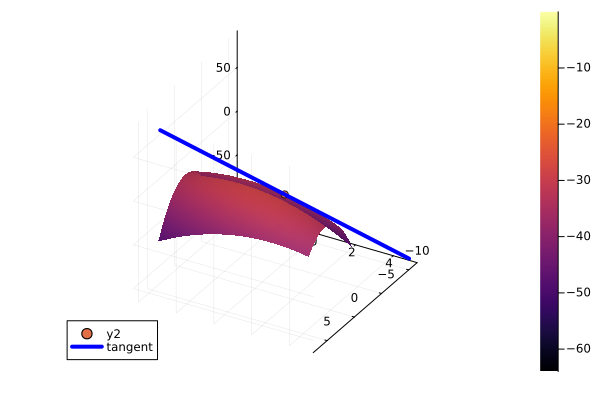

In [71]:
# functia g de doua variabile, tangenta in punctul x0, y0 cu panta cea mai mare 
# pe directia gradientului

# varianta 1: cand functia are derivate care contin si pe x si pe y
using SymEngine
using Plots; 

xx=range(-4,stop=4,length=50)
yy=range(-4,stop=4,length=50)
@vars x,y

g= -x^2-2y^2+x*y
x0, y0=1,-2
dfx=(r,t)->diff(g,x)(r,t)
dfy=(r,t)->diff(g,y)(r,t)

plot(xx,yy,g,st=:surface,camera=(-30,-30))

fx,fy, z0=dfx(x0,y0), dfy(x0,y0),float(g(x0,y0))
z(w,t)=z0+fx*(w-x0)+fy*(t-y0)
a,b=[float(x0+fx),float(y0+fy), float(z(x0+fx,y0+fy))],[float(x0-fx),float(y0-fy), float(z(x0-fx,y0-fy))]

scatter3d!([x0],[y0],[z0])
plot!([x0,a[1],b[1]], [y0,a[2],b[2]], [z0,a[3],b[3]], color="blue", linewidth=4, label="tangent")


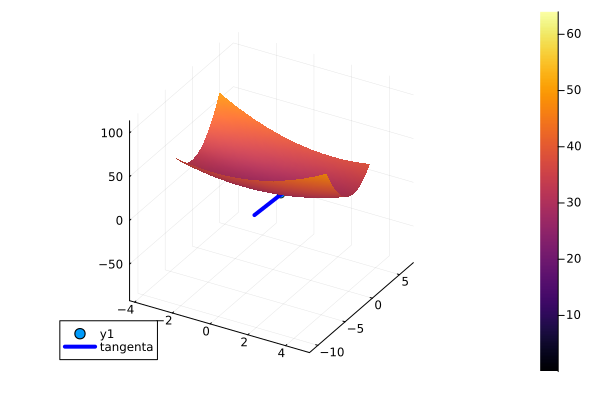

In [72]:
# functia g de doua variabile, tangenta in punctul x0, y0 cu panta cea mai mare 
# pe directia gradientului

# varianta 1: cand functia are derivate care contin si pe x si pe y
using SymEngine
using Plots; 

xx=range(-4,stop=4,length=50)
yy=range(-4,stop=4,length=50)
@vars x,y

g= -(-x^2-2y^2+x*y)
x0, y0=1,-2
dfx=(r,t)->diff(g,x)(r,t)
dfy=(r,t)->diff(g,y)(r,t)



fx,fy, z0=dfx(x0,y0), dfy(x0,y0),float(g(x0,y0))
z(w,t)=z0+fx*(w-x0)+fy*(t-y0)
a,b=[float(x0+fx),float(y0+fy), float(z(x0+fx,y0+fy))],[float(x0-fx),float(y0-fy), float(z(x0-fx,y0-fy))]

scatter3d([x0],[y0],[z0])
plot!([x0,a[1],b[1]], [y0,a[2],b[2]], [z0,a[3],b[3]], color="blue", linewidth=4, label="tangenta")
plot!(xx,yy,g,st=:surface,camera=(30,30))


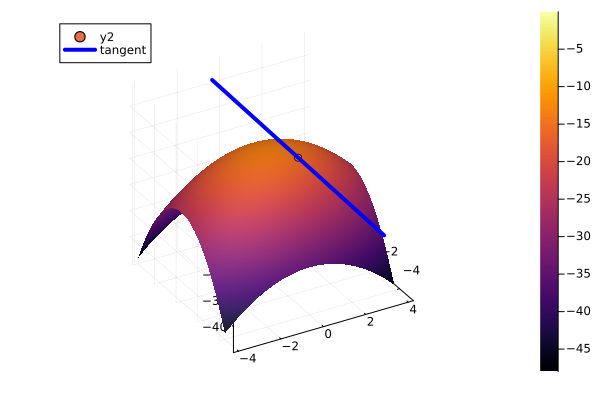

In [73]:

# varianta 2: cand derivata dupa y e doar functie de y0


xx=range(-4,stop=4,length=50)
yy=range(-4,stop=4,length=50)
@vars x,y

g= -x^2-2y^2
x0, y0=1,-1
dfx=(r,t)->diff(g,x)(r,t)
dfy=(r,t)->diff(g,y)(t)

plot(xx,yy,g,st=:surface,camera=(-30,30))

fx,fy, z0=dfx(x0,y0), dfy(x0,y0),float(g(x0,y0))
z(w,t)=z0+fx*(w-x0)+fy*(t-y0)
a,b=[float(x0+fx),float(y0+fy), float(z(x0+fx,y0+fy))],[float(x0-fx),float(y0-fy), float(z(x0-fx,y0-fy))]

scatter3d!([x0],[y0],[z0])
plot!([x0,a[1],b[1]], [y0,a[2],b[2]], [z0,a[3],b[3]], color="blue", linewidth=4, label="tangent")


### Exercise 1 — Gradient by hand

Consider

$
f(x,y)=x^2+2y^2-xy.
$

1. Compute $\frac{\partial f}{\partial x}$ and $\frac{\partial f}{\partial y}$.
2. Write the gradient $\nabla f(x,y)$.
3. Evaluate the gradient at $(1,-2)$.
4. What direction should we follow if we want to **decrease** the value of $f$ as rapidly as possible?

Write your calculations in a Markdown cell and verify them with Julia below.


In [74]:
# Exercise 1
# Define the symbolic function and compute its partial derivatives.


### Exercise 2 — Visualize a gradient direction

Choose a point $(x_0,y_0)$ different from the one used above.

Modify the previous plotting code so that it displays:

- the surface;
- your chosen point;
- the direction of the gradient at that point.

Then repeat the plot using the **negative gradient** direction.

**Question:** Which direction corresponds to local descent?


In [75]:
# Exercise 2
# Choose a new point and adapt the visualization.


## 2. Gradient descent

Gradient descent updates the current solution according to


$$x_{k+1}=x_k-\alpha\nabla f(x_k),$$


where:

- $x_k$ is the current point;
- $\nabla f(x_k)$ is the gradient;
- $\alpha>0$ is the **learning rate** or step size.

The learning rate is important:

- if $\alpha$ is too small, convergence can be very slow;
- if $\alpha$ is too large, the algorithm can overshoot the minimum or diverge;
- a suitable value allows steady progress toward a local minimum.

The next cells implement a simple reusable gradient-descent method.


In [76]:
abstract type DescentMethod end

struct GradientDescent <: DescentMethod
    α
end
init!(M::GradientDescent, f, ∇f, x) = M
function step!(M::GradientDescent, f, ∇f, x)
    α, g = M.α, ∇f(x)
    return x - α * g
end

step! (generic function with 2 methods)

In [77]:
f(x)= -x[1]^2-2x[2]^2+x[1]*x[2]
∇f(x)=[-2x[1]+x[2],-4x[2]+x[1]]
x=[1,-2]

2-element Vector{Int64}:
  1
 -2

In [78]:
f(x), ∇f(x)

(-11, [-4, 9])

In [79]:
M=GradientDescent(3)


GradientDescent(3)

In [80]:
M.α

3

In [81]:


init!(M, f, ∇f,x)

GradientDescent(3)

In [82]:

x1=step!(M, f, ∇f,x)


2-element Vector{Int64}:
  13
 -29

In [83]:
f(x1)

-2228

In [84]:
N = 20 # number of iterations
Solutions = []
f(x)= -(-x[1]^2-2x[2]^2+x[1]*x[2])
∇f(x)=-[-2*x[1]+x[2],-4*x[2]+x[1]]
x=[1,-2]
M=GradientDescent(0.3)
init!(M, f, ∇f,x)
Solutions= zeros(N,2)
for iteration in 1:N
    x=step!(M, f, ∇f,x)
    Solutions[iteration, : ]=x
end
Solutions



20×2 Matrix{Float64}:
 -0.2           0.7
  0.13         -0.2
 -0.008         0.079
  0.0205       -0.0182
  0.00274       0.00979
  0.004033     -0.001136
  0.0012724     0.0014371
  0.00094009    9.43e-5
  0.000404326   0.000263167
  0.00024068    6.86644e-5
  0.000116872   5.84713e-5
  6.429e-5      2.33672e-5
  3.27262e-5    1.46136e-5
  1.74745e-5    6.89514e-6
  9.05835e-6    3.86333e-6
  4.78234e-6    1.94484e-6
  2.49639e-6    1.04573e-6
  1.31228e-6    5.3977e-7
  6.86841e-7    2.85729e-7
  3.60455e-7    1.48907e-7

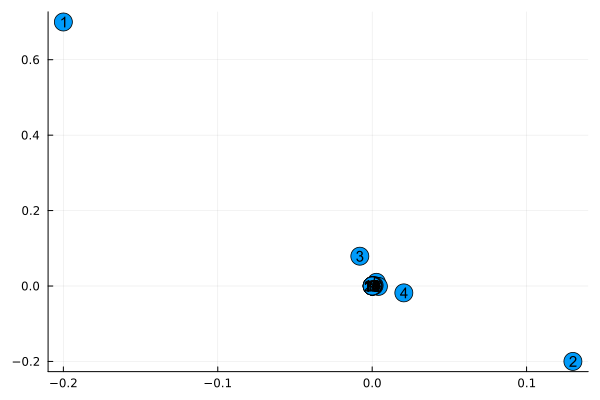

In [85]:
scatter(Solutions[:,1], Solutions[:,2], 
    series_annotations=Plots.series_annotations(1:N, Plots.font("Arial", 10
    )),
    markersize=10,
   legend = false)
    # plot!(Solutions[:,1], Solutions[:,2], arrow=true)


# scatter(Solutions[:,1], Solutions[:,2], xlim=(-0.005,0.005),
#     series_annotations=Plots.series_annotations(1:N, Plots.font("Arial", 10
#     )),
#     markersize=10,
#    legend = false)
#     # plot!(Solutions[:,1], Solutions[:,2], arrow=true)

In [86]:
using Optim

### Exercise 3 — One gradient-descent step

For


$$f(x_1,x_2)=x_1^2+2x_2^2-x_1x_2,$$


use the starting point $
x_0=(1,-2) $


and learning rate $\alpha=0.1$.

1. Compute $\nabla f(x_0)$ by hand.
2. Compute $x_1=x_0-\alpha\nabla f(x_0)$.
3. Compute $f(x_0)$ and $f(x_1)$.
4. Verify your calculations using the `GradientDescent` implementation.


In [87]:
# Exercise 3

# f(x) = ...
# ∇f(x) = ...
# x0 = ...
# M = GradientDescent(...)

# x1 = step!(...)
# Compare f(x0) and f(x1).


### Exercise 4 — Investigating the learning rate

Run gradient descent on the same convex quadratic function for each value


$$\alpha\in\{0.01,\;0.05,\;0.1,\;0.3,\;0.7\}.$$


Use the same initial point and the same number of iterations.

For each learning rate:

1. store the iterates;
2. store the objective values;
3. determine whether the method appears to converge;
4. compare the speed of convergence.

Create a plot of **objective value versus iteration**.

**Discussion:** What happens when the learning rate becomes too large?


In [88]:
# Exercise 4

alphas = [0.01, 0.05, 0.1, 0.3, 0.7]

# Run gradient descent for each learning rate.
# Store the objective values and create a comparison plot.


5-element Vector{Float64}:
 0.01
 0.05
 0.1
 0.3
 0.7

### Exercise 5 — Stopping criterion

The previous implementation runs for a fixed number of iterations. In practice, we often stop when


$$\|\nabla f(x_k)\| < \varepsilon.$$


Write a function

```julia
gradient_descent(f, ∇f, x0, α; ϵ=1e-6, k_max=1000)
```

that stops when either:

- the gradient norm is smaller than `ϵ`, or
- the number of iterations reaches `k_max`.

Return the final solution and the number of iterations.


In [89]:
# Exercise 5

function gradient_descent(f, ∇f, x0, α; ϵ=1e-6, k_max=1000)
    # Your implementation here
end


gradient_descent (generic function with 1 method)

## 3. Momentum

Standard gradient descent uses only the gradient at the current point. Momentum also keeps information about the previous movement.

A common update is


$v_{k+1}=\beta v_k-\alpha\nabla f(x_k),$


followed by


$x_{k+1}=x_k+v_{k+1}.$


Here:

- $\alpha$ is the learning rate;
- $v_k$ is the velocity;
- $\beta\in[0,1)$ controls how much of the previous velocity is retained.

Momentum can accelerate movement along consistent descent directions and reduce oscillation in narrow valleys.


In [90]:
mutable struct Momentum <: DescentMethod
    α # learning rate
    β # momentum decay
    v # momentum
end
function init!(M::Momentum, f, ∇f, x)
    M.v = zeros(length(x))
    return M
end
function step!(M::Momentum, f, ∇f, x)
    α, β, v, g = M.α, M.β, M.v, ∇f(x)
    v[:] = β * v - α * g
    return x + v
end

step! (generic function with 2 methods)

In [91]:
x 

2-element Vector{Float64}:
 3.604550437254099e-7
 1.4890657040889997e-7

[-0.00404276819945128, -0.00808553639890256] [0.9959572318005487, 1.9919144636010975]
[-0.007830687184180826, -0.015661374368361652] [0.988126544616368, 1.976253089232736]
[-0.011542839349082675, -0.02308567869816535] [0.9765837052672853, 1.9531674105345707]
[-0.015364703801463226, -0.030729407602926452] [0.9612190014658221, 1.9224380029316441]
[-0.019512299323440247, -0.039024598646880494] [0.9417067021423818, 1.8834134042847637]
[-0.02426578218695704, -0.04853156437391408] [0.9174409199554248, 1.8348818399108495]
[-0.03002395959075965, -0.0600479191815193] [0.8874169603646651, 1.7748339207293302]
[-0.03740222944666137, -0.07480445889332274] [0.8500147309180037, 1.7000294618360074]
[-0.047422515764433334, -0.09484503152886667] [0.8025922151535704, 1.6051844303071408]
[-0.061906000518974526, -0.12381200103794905] [0.7406862146345958, 1.4813724292691917]
[-0.08432296299898603, -0.16864592599797207] [0.6563632516356098, 1.3127265032712196]
[-0.12157818594144457, -0.24315637188288913] [0.

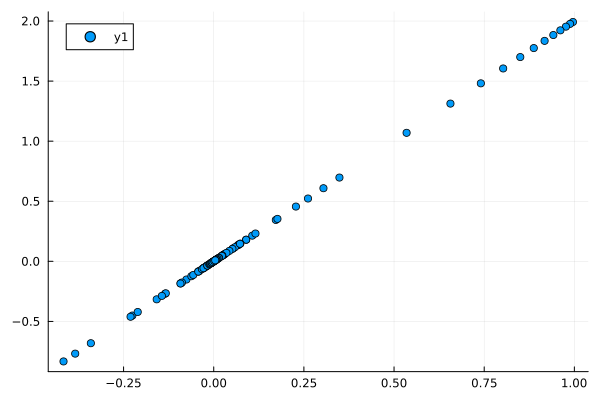

In [92]:
N = 100 # number of iterations

# f(x)= -(-x[1]^2-2x[2]^2+x[1]*x[2])
# ∇f(x)=-[-2*x[1]+x[2],-4*x[2]+x[1]]
# x=[1,-2]

f(x)=- exp(-x[1]^2-x[2]^2)
∇f(x)=[2*x[1]*exp(-x[1]^2-x[2]^2),2*x[2]*exp(-x[1]^2-x[2]^2)]
x=[1,2]

M=Momentum(0.3, 0.9, zeros(2))
init!(M, f, ∇f,x)
Solutions= zeros(N,2)
for iteration in 1:N
    x=step!(M, f, ∇f,x)
    println(M.v, " ",x)
    Solutions[iteration, : ]=x

end


scatter(Solutions[:,1], Solutions[:,2])


### Exercise 6 — Gradient descent versus momentum

Use the function

$$
f(x_1,x_2)=x_1^2+10x_2^2.
$$

Start from $x_0=(3,3)$.

Compare:

1. standard gradient descent;
2. momentum with $\beta=0.9$.

Use the same learning rate for both methods.

Plot the iterates in the $(x_1,x_2)$-plane and compare their trajectories.

**Questions**

- Which method reaches the neighborhood of the minimum faster?
- Do you observe oscillations?
- What happens if you change $\beta$ to `0.5` or `0.99`?


In [93]:
# Exercise 6

# Define f and ∇f.
# Run GradientDescent.
# Run Momentum.
# Plot both trajectories.


## 4. Newton's method

Gradient descent uses only **first-order information**. Newton's method also uses the Hessian matrix

$$
H(x)=\nabla^2f(x),
$$

which contains the second-order partial derivatives.

The Newton step is obtained by solving

$$
H(x_k)\Delta_k=\nabla f(x_k),
$$

and updating

$$
x_{k+1}=x_k-\Delta_k.
$$

In Julia, it is preferable to solve the linear system with

```julia
H(x) \ ∇f(x)
```

rather than explicitly computing `inv(H(x)) * ∇f(x)`.

Near a suitable local minimum, Newton's method can converge much faster than gradient descent. However, it requires a Hessian and can behave poorly if the Hessian is singular or does not provide a descent direction.


In [94]:
using LinearAlgebra

In [95]:

function newtons_method(∇f, H, x, ϵ, k_max)
    """
    Newton’s method,
    which takes the gradient of the
    function ∇f, the Hessian of the ob-
    jective function H, an initial point x,
    a step size tolerance ϵ, and a maxi-
    mum number of iterations k_max.
    """
    k, Δ = 1, fill(Inf, length(x))
    while norm(Δ) > ϵ && k ≤ k_max
        Δ = H(x) \ ∇f(x)
        x -= Δ
        k += 1
        @info "x=$(x), Δ=$(Δ), iteration = $(k)"
    end
    return x

end



newtons_method (generic function with 1 method)

In [96]:
booth(x) = (x[1]+2x[2]-7)^2 + (2x[1]+x[2]-5)^2
∇booth(x)=[10x[1]+8x[2]-34, 8x[1]+10x[2]-38]
H(x)=[10 8; 8 10]

H (generic function with 1 method)

In [97]:
x=[9,8]

2-element Vector{Int64}:
 9
 8

In [98]:
newtons_method(∇booth, H, x,0.004, 10 )

[ Info: x=[0.9999999999999982, 3.0000000000000018], Δ=[8.000000000000002, 4.999999999999998], iteration = 2
[ Info: x=[0.9999999999999982, 3.0000000000000018], Δ=[0.0, 0.0], iteration = 3


2-element Vector{Float64}:
 0.9999999999999982
 3.0000000000000018

In [99]:
H(0)


2×2 Matrix{Int64}:
 10   8
  8  10

In [100]:
inv(H(0))

2×2 Matrix{Float64}:
  0.277778  -0.222222
 -0.222222   0.277778

In [101]:
det(H(0))

36.0

In [102]:
HH=[10//1 8//1; 8//1 10//1]

2×2 Matrix{Rational{Int64}}:
 10   8
  8  10

In [103]:
inv(HH)

2×2 Matrix{Rational{Int64}}:
  5//18  -2//9
 -2//9    5//18

In [104]:
2/3

0.6666666666666666

In [105]:
2//3

2//3

### Exercise 7 — Newton's method for a quadratic function

Consider

$$
f(x,y)=2x^2+xy+2y^2-5x-6y.
$$

1. Compute the gradient.
2. Compute the Hessian.
3. Check whether the Hessian is positive definite.
4. Starting from $x_0=(0,0)$, apply Newton's method.
5. How many iterations are required to reach the minimizer?

Use the function `newtons_method` defined above.


In [106]:
# Exercise 7

# Define f, ∇f and H.

# Choose x0 = [0.0, 0.0]
# Run newtons_method(...)


### Exercise 8 — Compare gradient descent and Newton's method

Use the **Booth function**

$$
f(x,y)=(x+2y-7)^2+(2x+y-5)^2.
$$

Starting from the same point:

1. run gradient descent;
2. run Newton's method;
3. record the objective value after each iteration;
4. compare the number of iterations required by the two methods.

**Question:** Why is Newton's method particularly effective for this quadratic objective?


In [107]:
# Exercise 8

# Compare the two methods using the Booth function.


## 5. Symbolic derivatives and the Hessian

For more complicated functions, Julia's symbolic-computation packages can help verify derivatives.

For a two-variable function $f(x,y)$,

$$
\nabla f(x,y)=
\begin{bmatrix}
f_x\\
f_y
\end{bmatrix},
$$

and the Hessian is

$$
H(x,y)=
\begin{bmatrix}
f_{xx} & f_{xy}\\
f_{yx} & f_{yy}
\end{bmatrix}.
$$

For sufficiently smooth functions, the mixed derivatives satisfy

$$
f_{xy}=f_{yx}.
$$

The following cells use `SymEngine` to compute these derivatives symbolically.


In [108]:
f(x)=4 + x[1]^3 + x[2]^3 - 3 * x[1] *x[2]

f (generic function with 1 method)

In [109]:
using SymEngine

In [110]:
@vars x,y

gg = 4 + x^3 + y^3-3 *x* y



4 - 3*x*y + x^3 + y^3

In [111]:
diff(gg,x)

-3*y + 3*x^2

In [112]:
diff(gg,y)

-3*x + 3*y^2

In [113]:
diff(diff(gg,x),x),diff(diff(gg,x),y),diff(diff(gg,y),y)

(6*x, -3, 6*y)

In [114]:
HH = [diff(diff(gg,x),x) diff(diff(gg,x),y); diff(diff(gg,x),y) diff(diff(gg,y),y)]

2×2 Matrix{Basic}:
 6*x   -3
  -3  6*y

In [115]:
HHH(x)=[6*x[1]   -3;-3  6*x[2]]

HHH (generic function with 1 method)

In [116]:
x=[2,3]
HHH(x)

2×2 Matrix{Int64}:
 12  -3
 -3  18

### Exercise 9 — Symbolic gradient and Hessian

For

$$
f(x,y)=x^4+2x^2y+y^2,
$$

use `SymEngine` to compute:

1. $f_x$ and $f_y$;
2. $f_{xx}$, $f_{xy}$, and $f_{yy}$;
3. the Hessian matrix.

Evaluate the Hessian at $(1,2)$.


In [118]:
# Exercise 9

@vars x y

# Define the symbolic function.
# Compute the gradient and Hessian.
# Evaluate the Hessian at (1, 2).


(x, y)

### Exercise 10 — Classifying a stationary point

Consider

$$
f(x,y)=x^2-y^2.
$$

1. Find the stationary point by solving $\nabla f=0$.
2. Compute its Hessian.
3. Compute the eigenvalues of the Hessian.
4. Based on the eigenvalues, classify the stationary point as a local minimum, local maximum, or saddle point.
5. Plot the surface and verify your conclusion visually.


In [119]:
# Exercise 10

# Define f, its gradient, and Hessian.
# Compute the eigenvalues.
# Plot the surface.
